## First step

In the first step, we search for the best parameters with the use of Grid Search, then train our SVM model.

It is presumed that you have used the previous parts of the HerbCoRe tool to construct your database, and that your training data already has their features extracted.

In [1]:
from bibliotecas import *

In [10]:
def load_data(arq1, arq2, arq3):
    f1 = np.load(arq1)
    f2 = np.load(arq2)
    f3 = np.load(arq3)

    X = np.vstack([f1, f2, f3])  # concatenate all
    y = np.array([0]*len(f1) + [1]*len(f2) + [2]*len(f3))  # f1=0, f2=1, f3=2

    return X, y

def grid_search(X=None, y=None, arq1=None, arq2=None, arq3=None):
    if not (arq1 and arq2 and arq3):
        raise ValueError("the .npy files have to be provided in order to use grid search.")
    X, y = load_data(arq1, arq2, arq3)

    graus = [0, 1, 5]
    cs = [0.1, 1, 10, 100, 1000] 
    gammas = [2e-5, 2e-3, 2e-1, "auto", "scale"]

    param_grid = [
        {'kernel': ['linear'], 'C': cs},
        {'kernel': ['poly'], 'C': cs, 'degree': graus, 'gamma': gammas},
        {'kernel': ['rbf'], 'C': cs, 'gamma': gammas}
    ]

    model = SVC()
    gridSearch = GridSearchCV(estimator=model, param_grid=param_grid, cv=5)
    gridSearch.fit(X, y)
    
    print(f'the better choice of parameters is: {gridSearch.best_estimator_}')
    return gridSearch

In [13]:
# change the archive path for the .npy path of your training's extracted features
result_grid = grid_search(arq1='imagens-saida/f1.npy', arq2='imagens-saida/f2.npy', arq3='imagens-saida/f3.npy')

better_params = result_grid.best_params_
best_kernel = better_params['kernel']
best_c = better_params['C']

the better choice of parameters is: SVC(C=0.1, kernel='linear')


In [16]:
def set_svm(kernel, c):
    return SVC(kernel=best_kernel, C=best_c)

In [26]:
def avaliar_modelo(X, y, arq1, arq2, arq3, n_splits=5, dir_images=None, matriz=False):
    svm = set_svm(best_kernel, best_c)
    seed = random.randint(0, 10000)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    f1_folds = []

    if dir_images is None:
        print("\nbase path for images not provided. mistakes will not provide images")
    else:
        print(f"\npath used for images: {dir_images}")

    len_f1 = np.load(arq1).shape[0] # shape to report
    len_f2 = np.load(arq2).shape[0]
    len_f3 = np.load(arq3).shape[0]

    y_true_all = [] # for confusion matrix
    y_pred_all = [] 

    scaler = StandardScaler()

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1): # for each fold (X, y)
        X_train = X[train_idx] 
        X_test  = X[test_idx] 

        y_train = y[train_idx] # labels
        y_test  = y[test_idx] 

        scaler = scaler # z-score
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        svm.fit(X_train, y_train) # train
        y_pred = svm.predict(X_test) # predict

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        f1 = f1_score(y_test, y_pred, average='weighted')
        f1_folds.append(f1)
        print(f"fold's {fold} f1 score was {f1:.4f}")

        error_reports(y_test, y_pred, test_idx, len_f1, len_f2, len_f3, dir_images)

    media_f1 = np.mean(f1_folds)
    desvio_f1 = np.std(f1_folds)

    print(f"average f1: {(media_f1):.4f}")
    print(f"standard deviation: {np.std(f1_folds):.4f}")

    if(matriz):
        confusion_matrixx(y_true_all, y_pred_all, labels_class=["Exsiccatae", "Labels", "Live plants"])

    return media_f1, desvio_f1

In [27]:
def error_reports(y_test, y_pred, test_idx, len_f1, len_f2, len_f3, dir_images):
    erros = np.where(y_pred != y_test)[0] # onde a predição foi diferente do valor real

    if(erros.size > 0):
        print("samples classifed incorrectly:")
        for i in erros: # para cada erro
            global_idx = test_idx[i] # índice original (ordem numérica nas pastas)
            true_label = y_test[i] # rótulo real
            pred_label = y_pred[i] # rótulo predito pela svm

            # de qual classe veio a amostra
            if global_idx < len_f1: # primeira classe
                classe_real = "f1"
            elif global_idx < len_f1 + len_f2: # segunda classe
                classe_real = "f2"
            else: # terceira classe
                classe_real = "f3"

            if dir_images: # diretório informado
                pasta_classe = os.path.join(dir_images, "images", "tf.keras", classe_real) # caminho da pasta
                arquivos = glob.glob(os.path.join(pasta_classe, "*.jpg")) # lista todos os arquivos da pasta

                if arquivos: # encontrou arquivos
                    caminho = arquivos[global_idx % len(arquivos)]  # pega um arquivo da classe
                    print(f"  [label era {true_label} ({classe_real}) - predizeu {pred_label} (0=f1, 1=f2, 2=f3)], imagem:  {caminho}")
                else: # não encontrou arquivos
                    print(f"  [label era {true_label} ({classe_real}) - predizeu {pred_label} (0=f1, 1=f2, 2=f3)], nenhuma imagem encontrada")
            else: # diretório não foi informado, usa posição global dentro das pastas
                print(f"  [label era {true_label} - predizeu {pred_label} (0=f1, 1=f2, 2=f3)], sem diretório, índice {global_idx}")

In [28]:
def confusion_matrixx(y_true, y_pred, labels_class=None):
    cm = confusion_matrix(y_true, y_pred)

    if labels_class is None:
        labels_class = ["Exsiccatae", "Labels", "Live plants"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=labels_class, yticklabels=labels_class)
    plt.xlabel("Predicted class")
    plt.ylabel("Real class")
    plt.title("Confusion matrix")
    plt.show()
    
    return cm


path used for images: imagens-saida
fold's 1 f1 score was 1.0000
fold's 2 f1 score was 1.0000
fold's 3 f1 score was 0.9484
samples classifed incorrectly:
  [label era 2 (f3) - predizeu 0 (0=f1, 1=f2, 2=f3)], imagem:  imagens-saida\images\tf.keras\f3\HUFSJ012496_v03_patch=1+1+c=0.00.jpg
fold's 4 f1 score was 1.0000
fold's 5 f1 score was 1.0000
average f1: 0.9897
standard deviation: 0.0206


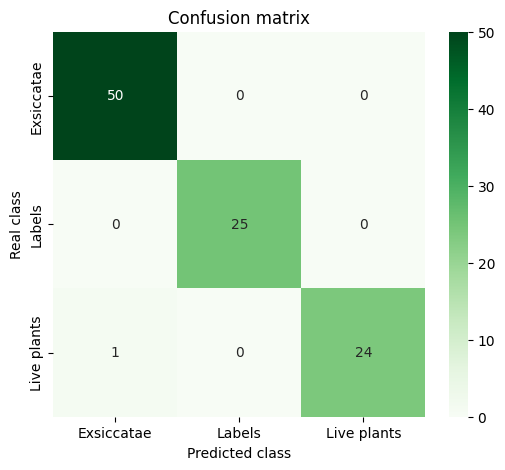

In [29]:
X, y = load_data('imagens-saida/f1.npy', 'imagens-saida/f2.npy', 'imagens-saida/f3.npy')

media, desvio = avaliar_modelo(X=X, y=y, arq1='imagens-saida/f1.npy', arq2='imagens-saida/f2.npy', arq3='imagens-saida/f3.npy', dir_images='imagens-saida', matriz=True)
